In [1]:
import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os


from torchdiffeq import odeint

/home/shobs/anaconda3/envs/neuro/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:

import gc
import os
import sys
import time

import h5py
import mne
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from torchdiffeq import odeint, odeint_adjoint
import matplotlib.pyplot as plt

CONFIG = {

    "fif_path":  '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif',
    "mat_path":  "/home/shobs/Desktop/DDP/scout_id_309.mat",
    "sc_path":   "/home/shobs/Desktop/DDP/SC_CC120309-27.mat",

    "ecg_channel_idx": 322,      # raw channel index for ECG (inverted)
    "target_eeg_idx":  1,        # which EEG region to model
    "fs_raw":          1000,     # raw sampling rate  [Hz]
    "fs_model":        100,      # model sampling rate [Hz]
    "train_sec":       10,       # seconds used for training
    "test_sec":        5,        # seconds used for testing
    "start_idx":       2000,     # sample offset into the recording

    # ── Preprocessing ─────────────────────────────────────────────────────────
    "ecg_lowcut":  1.5,          # ECG bandpass low  [Hz]
    "ecg_highcut": 20.0,         # ECG bandpass high [Hz]
    "eeg_lowcut":  0.5,          # EEG bandpass low  [Hz]
    "eeg_highcut": 20.0,         # EEG bandpass high [Hz]
    "butter_order": 4,

    # ── Structural connectivity ───────────────────────────────────────────────
    "sc_scale":       0.01,       # SC matrix normalisation scale
    "sc_percentile":  70,        # sparsity threshold percentile
    "sc_osc_scale":   10.0,      # after expanding to oscillator resolution

    # ── Brain oscillator layout ───────────────────────────────────────────────
    "osc_per_region":  4,        # oscillators per brain region
    "freq_low_hz":     1.0,      # random freq lower bound [Hz]
    "freq_high_hz":   20.0,      # random freq upper bound [Hz]
    "intra_coupling":  0.0001,   # intra-region coupling strength
    "brain_seed":      42,

    # ── Heart oscillator (Stuart-Landau) ─────────────────────────────────────
    "heart_alpha":      1.0,
    "heart_omega1":     7.6,    # [rad/s]
    "heart_omega2":     7.7,     # [rad/s]
    "heart_A_init":     0.0001,
    "heart_theta_init": 3.14159265358979,   # np.pi
    "heart_n":          1.0,
    "heart_mod_scale":  0.1,     # modulation strength on heart oscillator

    # ── HeartModel MLP ───────────────────────────────────────────────────────
    "heart_input_dim":   4,
    "heart_hidden_dim":  100,
    "heart_feature_dim": 50,
    "heart_output_dim":  1,
    "heart_dropout":     0.1,

    # ── Stage 1 – heart training ──────────────────────────────────────────────
    "heart_epochs":      120000,
    "heart_lr":          1e-3,
    "heart_sched_factor":  0.5,
    "heart_sched_patience": 500,
    "heart_log_every":   2500,

    # ── Brain ODE (TorchRevHopf) ─────────────────────────────────────────────
    "brain_mu": 1.0,

    # ── Stage 1 – brain pre-train ─────────────────────────────────────────────
    "brain_epochs":      200,    # ↑ from 300 for better convergence
    "brain_lr_omega":    1e-2,
    "brain_lr_alpha":    1e-2,
    "brain_lr_theta":    1e-3,
    "brain_sched_factor":  0.5,
    "brain_sched_patience": 20,
    "brain_settle":      10,     # warmup steps to ignore
    "brain_corr_weight":  1.0,   # weight for correlation loss
    "brain_scale_weight": 0.1,   # weight for scale matching loss
    "brain_alpha_pen":    0.2,   # weight for alpha-collapse penalty
    "brain_grad_clip":    1.0,
    "brain_log_every":   50,

    # ── ECGToOscillatorMLP ────────────────────────────────────────────────────
    "vns_n_osc":    18,          # oscillators on the VNS pathway
    "vns_hidden":   64,
    "vns_seed":     42,
    "vns_sparsity": 0.3,

    # ── Stage 2 – ECG→Brain training ─────────────────────────────────────────
    "stage2_epochs":      200,   # ↑ from 300
    "stage2_lr":          5e-3,
    "stage2_sched_factor":  0.3,
    "stage2_sched_patience": 15,
    "stage2_sched_threshold": 1e-3,
    "stage2_sched_cooldown":  5,
    "stage2_min_lr":     1e-5,
    "stage2_settle_frac": 0.1,  # fraction of steps to skip in loss
    "stage2_grad_clip":   1.0,
    "stage2_log_every":  10,
    "brain_eta_omega": 0.05,
    "brain_eta_alpha": 0.03,
    "brain_eta_theta": 0.05,
    "stage2_alpha_lr":  1e-3,    # separate LR for learnable alpha in Stage 2
    "stage2_alpha_reg": 0.01,
    "stage2_hidden_noise": 0.01,

    # ── BrainToHeartFeedbackMLP ───────────────────────────────────────────────
    "feedback_n_vns":  12,
    "feedback_hidden": 64,
    "feedback_seed":   99,

    # ── Stage 4 – feedback training ───────────────────────────────────────────
    "stage4_epochs":        10,   # ↑ from 100 for better ECG test score
    "stage4_lr":            1e-3,
    "stage4_sched_factor":  0.5,
    "stage4_sched_patience": 20,
    "stage4_min_lr":        1e-5,
    "stage4_grad_clip":     1.0,
    "stage4_log_every":     20,
}

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20, order= 4):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized ## I will change this


def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total = num_regions * osc_per_region
    return 2 * np.pi * np.random.uniform(low, high, total)


def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            si, ei = i * osc_per_region, (i + 1) * osc_per_region
            sj, ej = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[si:ei, sj:ej] = intra_value
            else:
                blk = np.random.rand(osc_per_region, osc_per_region)
                blk *= Sc_region[i, j] / (blk.sum() + 1e-9)
                Sc_full[si:ei, sj:ej] = blk
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full


def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()

class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        p = pred   - pred.mean()
        t = target - target.mean()
        num = (p * t).sum()
        den = torch.sqrt((p**2).sum() * (t**2).sum() + self.eps)
        return 1.0 - num / den


# ──────────────────────────────────────────────────────────────────────────────
# Heart sub-system ++ utility function
# ──────────────────────────────────────────────────────────────────────────────
def simulate_coupled_oscillators(T=10, dt=1/1000, alpha=1, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=3.14, n=1.0, modulation=None):
    N = int(T / dt)
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12 + (0.1*modulation[i,0] if modulation is not None and i < len(modulation) else 0)
        dr2 = alpha * r2 - r2**3 + coupling21 + (0.1*modulation[i,1] if modulation is not None and i < len(modulation) else 0)

        dphi1 = omega1 + A12 * r2 / r1 * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / r2 * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)

    def get_features(self, x):
        return self.feature_extractor(x)

## this part doesn't require================

class HeartOscillatorODEFunc(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.alpha      = cfg["heart_alpha"]
        self.A12        = cfg["heart_A_init"]
        self.A21        = cfg["heart_A_init"]
        self.n          = cfg["heart_n"]
        self.fs         = cfg["fs_model"]
        self.mod_scale  = cfg["heart_mod_scale"]
        self.omega1     = cfg["heart_omega1"]
        self.omega2     = cfg["heart_omega2"]
        self.modulation = None
        self.register_buffer("theta12", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))
        self.register_buffer("theta21", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))

    def forward(self, t, state):
        r1, phi1, r2, phi2 = state[0], state[1], state[2], state[3]
        r1 = torch.clamp(r1, 1e-6, 5.0)
        r2 = torch.clamp(r2, 1e-6, 5.0)

        c12 = self.A12 * r2 * torch.cos(self.theta12 + self.n * (phi2 - phi1))
        c21 = self.A21 * r1 * torch.cos(self.theta21 + self.n * (phi1 - phi2))

        if self.modulation is not None:
            t_idx = torch.clamp((t * self.fs).long(), 0, self.modulation.shape[0] - 1).item()
            mod   = self.modulation[t_idx]
            dr1   = (self.alpha - r1**2) * r1 + c12 + self.mod_scale * mod[0]
            dr2   = (self.alpha - r2**2) * r2 + c21 + self.mod_scale * mod[1]
        else:
            dr1 = (self.alpha - r1**2) * r1 + c12
            dr2 = (self.alpha - r2**2) * r2 + c21

        dphi1 = self.omega1 + self.A12 * (r2 / r1) * torch.sin(self.theta12 + self.n * (phi2 - phi1))
        dphi2 = self.omega2 + self.A21 * (r1 / r2) * torch.sin(self.theta21 + self.n * (phi1 - phi2))
        return torch.stack([dr1, dphi1, dr2, dphi2])


class HeartOscillatorLayer(nn.Module):
    """Differentiable coupled Stuart-Landau heart oscillator via ODE."""

    def __init__(self, cfg, device="cpu"):
        super().__init__()
        self.fs     = cfg["fs_model"]
        self.device = device
        self.ode_func = HeartOscillatorODEFunc(cfg)
        self.register_buffer("y0", torch.tensor([1.0, 0.0, 1.0, 0.0], dtype=torch.float32))

    def forward(self, T, modulation=None):
        self.ode_func.modulation = modulation
        t_eval = torch.arange(0, T, dtype=torch.float32, device=self.y0.device) / self.fs
        sol = odeint(self.ode_func, self.y0, t_eval, method="rk4")   # (T, 4)
        r1  = torch.clamp(sol[:, 0], 1e-6, 5.0)
        phi1 = sol[:, 1]
        r2  = torch.clamp(sol[:, 2], 1e-6, 5.0)
        phi2 = sol[:, 3]
        return torch.stack([
            r1 * torch.cos(phi1),
            r1 * torch.sin(phi1),
            r2 * torch.cos(phi2),
            r2 * torch.sin(phi2),
        ], dim=1)

## this part doesn't require................................

# ──────────────────────────────────────────────────────────────────────────────
# VNS oscillator sub-layer (shared by ECGToOscillatorMLP & BrainToHeartFeedbackMLP)
# ──────────────────────────────────────────────────────────────────────────────

class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta):
        super().__init__()

        self.N_osc = N_osc
        self.mu = mu
        self.k = k

        self.register_buffer("omega", omega)
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)

        self.r_min = 0.001
        self.r_max = 2.0
        self.phase_clip = 2 * np.pi

        # self.input_f = None # Removed this as input_f will be passed via args to forward

    def forward(self, t, state):

        N = self.N_osc

        r = state[:N].unsqueeze(-1)
        phi = state[N:].unsqueeze(-1)

        # Dynamically get the input_f for the current time t from the sequence
        # Access input_features_sequence and t_eval_input from self
        if hasattr(self, 'input_features_sequence') and hasattr(self, 't_eval_input'):
            t_eval_input = self.t_eval_input
            input_features_sequence = self.input_features_sequence
            # Ensure t_eval_input and t are on the same device
            t_idx = torch.argmin(torch.abs(t_eval_input.to(t.device) - t)).long()
            input_f = input_features_sequence[t_idx].unsqueeze(-1) # (N_osc, 1)
        else:
            # Default to zero if no input sequence is provided (e.g., initial ODE func creation or debugging)
            input_f = torch.zeros_like(r) # (N_osc, 1)

        omega_i = self.omega.unsqueeze(-1)
        omega_j = self.omega.unsqueeze(0)

        C = self.C
        theta = self.theta

        phi_i = phi
        phi_j = phi.transpose(0, 1)

        phase_term = phi_j / omega_j - phi_i / omega_i + theta / (omega_i * omega_j)

        phase_term = torch.clamp(
            phase_term,
            -self.phase_clip,
            self.phase_clip
        )

        r_j = r.transpose(0, 1)
        r_safe = torch.clamp(r, self.r_min, self.r_max)

        coupling_r = self.k * torch.sum(
            C * r_j * torch.cos(omega_i * phase_term),
            dim=-1,
            keepdim=True
        )

        coupling_phi = self.k * torch.sum(
            C * (r_j / r_safe) * torch.sin(omega_i * phase_term),
            dim=-1,
            keepdim=True
        )

        dr_dt = (self.mu - r**2) * r + coupling_r + input_f
        dphi_dt = self.omega.unsqueeze(-1) + coupling_phi

        return torch.cat([
            dr_dt.squeeze(-1),
            dphi_dt.squeeze(-1)
        ])


class OscillatorLayer(nn.Module):

    def __init__(self,
                 N_osc=16,
                 T=4.0,
                 fs=100,
                 device="cpu",
                 coupling_sparsity=0.3,
                 seed=42):

        super().__init__()

        self.N_osc = N_osc
        self.T = T
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        self.mu_param = nn.Parameter(torch.tensor(1.0, device=device))
        self.k_param = nn.Parameter(torch.tensor(0.01, device=device))
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)

        mask = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)

        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.C_buffer = C_val * mask.float()

        theta_val = torch.zeros(N_osc, N_osc, device=device)
        theta_val.fill_diagonal_(0.0)
        self.theta_buffer = theta_val

        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer
        )

        self.register_buffer("initial_r", torch.ones(N_osc, device=device) * 0.1)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features_sequence): # Renamed to emphasize it's a sequence

        # input_features_sequence: (T_steps, N_osc)

        y0 = torch.cat([
            self.initial_r,
            self.initial_phi
        ])

        t_eval = torch.arange(
            0,
            self.T,
            self.dt,
            device=input_features_sequence.device,
            dtype=torch.float32
        )

        # Set input_features_sequence and t_eval as attributes of ode_func
        self.ode_func.input_features_sequence = input_features_sequence
        self.ode_func.t_eval_input = t_eval

        sol = odeint(
            self.ode_func,
            y0,
            t_eval,
            method="rk4"
            # args parameter is removed here
        )

        # Clean up temporary attributes
        del self.ode_func.input_features_sequence
        del self.ode_func.t_eval_input

        return sol



# ──────────────────────────────────────────────────────────────────────────────
# ECG → Brain drive MLP  (Stage 2)
# ──────────────────────────────────────────────────────────────────────────────

class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=16, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(N_osc=N_VNS, device=device, coupling_sparsity=0.3, seed=42)
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS * 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # [batch, ecg_dim] or [ecg_dim]
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)  # (1, ecg_dim)

        ecg_features = (
            ecg_features - ecg_features.mean(dim=-1, keepdim=True)
        ) / (ecg_features.std(dim=-1, keepdim=True) + 1e-6)

        pre = self.pre_osc(ecg_features)
        osc_hidden = self.osc_layer(pre) # Shape (T_steps, 2 * N_VNS)

        # Extract only the radius component from the oscillator state
        # osc_hidden contains [r1, ..., rN_VNS, phi1, ..., phiN_VNS]
        # The first N_VNS elements are radii
        r_components = osc_hidden[:, :self.osc_layer.N_osc]
        combined = r_components # Now combined has shape (T_steps, N_VNS)

        brain_drive = self.post_osc(combined)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)  # (output_dim,)
        return brain_drive


# ──────────────────────────────────────────────────────────────────────────────
# Brain → model  (Stage 2)
# ──────────────────────────────────────────────────────────────────────────────
class ODEFuc(nn.Module):
    def __init__(self, mu, eta_theta, eta_omega, eta_alpha,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100):

        super().__init__()
        self.mu = mu
        self.eta_theta = eta_theta
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.D_function = D_function
        self.N = N
        self.fs = fs

        self.register_buffer(
            'Sc',
            torch.tensor(Sc, dtype=torch.float32)
        )

        self.brain_drive_full = brain_drive_full

    def forward(self, t, state):

        N = self.N

        r = state[:N]
        phi = state[N:2*N]
        theta = state[2*N:2*N + N**2].view(N, N)
        omega = state[2*N + N**2:3*N + N**2]
        alpha = state[3*N + N**2:4*N + N**2]

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r = torch.clamp(r, 1e-1, 2.0)
        alpha = torch.clamp(alpha, -1.0, 1.0)
        r_safe = torch.clamp(torch.where(r < 1e-6, torch.tensor(1e-6, device=r.device, dtype=r.dtype), r), 1e-5, 10.0)  # Higher min for stability
        r = r_safe


        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]), -1e2, 1e2)  # Added clamp to prevent extreme phases


        # ----- Target forcing -----
        D = torch.tensor(
            self.D_function(t.item()),
            device=state.device,
            dtype=state.dtype
        )

        P = torch.sum(alpha * r * torch.cos(phi))
        e = D - P

        # ----- Precomputed brain drive indexing -----
        if self.brain_drive_full is not None:
            t_idx = min(
                round(t.item() * self.fs),
                self.brain_drive_full.shape[0] - 1
            )
            ecg_input = self.brain_drive_full[t_idx]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        # ----- Dynamics -----
        # Safe Log-Domain Power
        #log_r = torch.log(r_safe)
        #r_power = torch.exp(omega_ratio * log_r[None, :])

        coupling_r = torch.sum(torch.abs(self.Sc) * r[None, :] * torch.cos(phase_diff), dim=1)

        drdt = (self.mu - r**2) * r \
               + coupling_r \
               + e * torch.cos(phi) \
               + ecg_input



        coupling_phi = torch.sum(torch.abs(self.Sc) * (r[None, :] / r_safe[:, None]) * torch.sin(phase_diff), dim=1)
        dphidt = omega + coupling_phi - (e / r_safe) * torch.sin(phi)

         # Adaptive dynamics (these are "frozen" by setting etas to 0 in Stage 2)
        dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
        domegadt = -self.eta_omega * e * torch.sin(phi)
        dalphadt = self.eta_alpha * e * r * torch.cos(phi)

        # Clamp gradients to prevent explosions

        ## Put a clamp  on drdt, domegadt to restrict the bound..
        return torch.cat([
            drdt.flatten(),
            dphidt.flatten(),
            dthetadt.flatten(),
            domegadt.flatten(),
            dalphadt.flatten()
        ])


class TorchRevHopfNetwork:
    def __init__(self, mu, eta_omega, eta_alpha, eta_theta,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100,
                 device="cuda"):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            eta_theta=eta_theta,
            eta_omega=eta_omega,
            eta_alpha=eta_alpha,
            D_function=D_function,
            N=N,
            Sc=Sc,
            brain_drive_full=brain_drive_full,
            fs=fs
        ).to(self.device)

    def solve(self, r0, phi0, theta0, omega0, alpha0, t_eval, use_adjoint=True):

        y0 = torch.tensor(
            np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(
            t_eval,
            device=self.device,
            dtype=torch.float32
        )

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )
        else:
    
            sol = odeint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )

        N = self.N

        r = sol[:, :N]
        phi = sol[:, N:2*N]
        theta = sol[:, 2*N:2*N + N**2].view(-1, N, N)
        omega = sol[:, 2*N + N**2:3*N + N**2]
        alpha = sol[:, 3*N + N**2:4*N + N**2]

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)

        return r, phi, theta, omega, alpha, rcos_phi


def train_heart_model(osc_train, ecg_target_signal, device):
    print("--- Starting Heart Model Pre-training ---")
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1000)
    criterion = nn.MSELoss()

    #sim_osc_input = torch.tensor(simulate_coupled_oscillators(T=4.0, dt=0.01), dtype=torch.float32).to(device)  ## used as prediction..
    sim_osc_input = torch.tensor(osc_train, dtype=torch.float32).to(device)
    #ecg_target = torch.tensor(ecg_target_signal[::10], dtype=torch.float32).to(device).unsqueeze(1)
    ecg_target = torch.tensor(ecg_target_signal, dtype=torch.float32).to(device).unsqueeze(1)
    # FIX 4 (support): collect loss history so we can plot it later
    heart_losses = []

    for epoch in range(125000):
        predicted_ecg = heart_model(sim_osc_input)
        loss = criterion(predicted_ecg, ecg_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        heart_losses.append(loss.item())
        if (epoch + 1) % 2500 == 0:
            print(f"Heart Epoch {epoch+1}, Loss: {loss.item():.6f}")
    print("--- Heart Pre-training Finished ---")
    return heart_model, heart_losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training ---")
    # NOTE: This stage is GRADIENT-FREE forward simulation.
    # It iteratively runs the ODE forward and uses the final state as the next
    # initial condition, effectively "warming up" the brain model's initial conditions.
    # No optimizer or loss.backward() is used here by design.
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 3
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    alpha_full = np.random.uniform(0.1, 0.7, 68 * osc_per_region)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.clip(np.concatenate([alpha_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices]), 0.05, 0.5)
    r0 = 0.1 * np.ones(N)
    #analytic = hilbert(D_function(t))
    #init_phase = np.angle(analytic[0])

    #phi0 = 0.1 * np.ones(N)
    phi0 = np.zeros(N)
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    model = TorchRevHopfNetwork(
        mu=1.0, eta_omega=0.05, eta_alpha=0.005, eta_theta=0.05,
        D_function=D_function, N=N, Sc=Sc_reduced_osc,
        device=device
    )

    criterion = nn.MSELoss()
    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    for epoch in range(200):
        with torch.no_grad():
            # use_adjoint=True is fine here since we don't need gradients
            r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, theta0, omega0, alpha0, t, use_adjoint=False)
            P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
            loss = criterion(P_out, D_true)
            losses.append(loss.item())

            theta0, omega0 = theta[-1].cpu().numpy(), omega[-1].cpu().numpy()
            alpha0 = alpha[-1].cpu().numpy()

        if (epoch + 1) % 10 == 0:
            print(f"Brain Epoch {epoch+1}/30, Loss: {loss.item():.6f}")

        # FIX 3: Free GPU memory after each epoch
        torch.cuda.empty_cache()
        gc.collect()

    final_params = {
        'r': 0.1 * np.ones(N),
        'phi': np.zeros(N),
        'theta': theta[-1].cpu().numpy(),
        'omega': omega[-1].cpu().numpy(),
        'alpha': alpha[-1].cpu().numpy()
    }
    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(
        trained_heart_model,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t,
        device):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=18,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    # FIX 8a: Lower LR from 1e-2 → 1e-3 to prevent divergence.
    # With standard odeint, gradients backprop through 200 ODE steps and can be
    # very large. A high LR causes the optimizer to overshoot → loss explodes.
    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=5e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=10,
        threshold=1e-3,
        cooldown=5,
        min_lr=1e-5
    )

    criterion = nn.MSELoss()

    # -------- Extract ECG features (frozen heart model) --------
    with torch.no_grad():
        sim_input = torch.tensor(
            simulate_coupled_oscillators(T=10, dt=0.01),
            dtype=torch.float32
        ).to(device)
        hidden_repr = trained_heart_model.get_features(sim_input)  # (T_steps, feature_dim)

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    # FIX 1 (CRITICAL): Create TorchRevHopfNetwork ONCE outside the loop.
    # Previously it was re-instantiated every epoch, causing massive GPU memory accumulation.
    # Now we create it once with brain_drive_full=None and update the attribute each epoch.
    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        device=device
    )

    for epoch in range(250):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  # (T_steps, N) — has grad_fn

        # FIX 8b: Scale and bound the brain drive with tanh * 0.1.
        # Without this, the MLP output is unbounded and can inject very large
        # values into drdt, destabilizing the ODE and causing loss to explode.
        brain_drive_full = (raw_drive)

        # Update brain_drive_full on the ODE func each epoch.
        # Stored as a plain attribute (not a buffer) so the autograd graph is preserved.
        model.ode_func.brain_drive_full = brain_drive_full

        # FIX 7 (CRITICAL): use_adjoint=False → standard odeint builds a full autograd
        # graph so gradients flow back through brain_drive_full to ecg_to_osc_mlp.
        # odeint_adjoint only tracks gradients through registered nn.Module parameters
        # and would raise: "element 0 of tensors does not require grad and does not have a grad_fn"
        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            initial_brain_params['theta'],
            initial_brain_params['omega'],
            initial_brain_params['alpha'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)

        mse_loss = criterion(P_out, D_true)

        # ---- analytic signal phase alignment ----
        #P_complex = torch.view_as_complex(
        #    torch.stack([P_out, torch.zeros_like(P_out)], dim=-1)
        #)

        #D_complex = torch.view_as_complex(
        #    torch.stack([D_true, torch.zeros_like(D_true)], dim=-1)
        #)

        #phase_loss = torch.mean(
        #    1 - torch.cos(
        #        torch.angle(P_complex) -
        #        torch.angle(D_complex)
        #    )
        #)

        loss = mse_loss

        #drive_energy = torch.mean(brain_drive_full**2)

        loss = loss   ## revoed the new version of regularization..

        settle = int(0.1 * model.ode_func.fs)   # ignore first 300 ms

        loss = (
            criterion(P_out[settle:], D_true[settle:])

        )
        optimizer.zero_grad()
        loss.backward()
        # FIX 8a (cont.): Gradient clipping prevents exploding gradients from the
        # deep ODE unroll (200 steps of backprop through Euler integration).
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch+1}, "
                f"Loss: {loss.item():.6f}, "
                f"LR: {current_lr:.3e}"
            )

        # FIX 3: Free GPU memory each epoch
        torch.cuda.empty_cache()
        gc.collect()

    return ecg_to_osc_mlp, losses



def run_pipeline_for_region(
    region_idx,
    cfg,
    raw,
    mat,
    Sw_all,
    non_zero_indices_per_row,
    ecg_processed,
    ecg_full_processed_fb,
    eeg_processed,
    t_full,
    t_train,
    t_test,
    D_full_func,
    device,

):
    print(f"\n================ REGION {region_idx} ================\n")

    cfg_local = cfg.copy()
    cfg_local["target_eeg_idx"] = region_idx

    region_dir = os.path.join(save_root, f"region_{region_idx}")
    os.makedirs(region_dir, exist_ok=True)

    target_indices = [1]
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Step 1: Pre-train heart model
    # FIX 4 (support): train_heart_model now also returns heart_losses for plotting
    dt = 0.01
    osc_train = simulate_coupled_oscillators(T=10, dt=dt)
    ecg_train = ecg_processed[::10]


    trained_heart_model, heart_losses = train_heart_model(osc_train,ecg_train, device)



    with torch.no_grad():
    # Change T=10 to T=2 to match the effective duration of ecg_target_signal
       simulated_ecg_input = torch.tensor(simulate_coupled_oscillators(T=4, dt=0.01), dtype=torch.float32).to(device)
    #simulated_ecg_input = torch.tensor(osc_train, dtype=torch.float32).to(device)
       hidden_repr = trained_heart_model.get_features(simulated_ecg_input)
    results_folder = "simulation_results"
    os.makedirs(results_folder, exist_ok=True)

    target_idx = target_indices[0]
    t_duration = 10
    fs = 100
    t = np.arange(0, t_duration, 1/fs)
    target_signal = eeg_processed[target_idx, ::10]
    D_function = interp1d(t, target_signal, kind='linear', bounds_error=False, fill_value=0.0)

   # Step 2: Stage 1 - Brain pre-training (gradient-free forward simulation)
    final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device
    )

    # ─────────────────────────────
    # Stage 3 –
    model = TorchRevHopfNetwork(
    mu=1.0,
    eta_omega=0.0,
    eta_alpha=0.0,
    eta_theta=0.0,
    D_function=D_function,
    N=N,
    Sc=Sc_reduced_osc,
    fs=100,
    device=device
    )

    r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
    final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
    final_brain_params['omega'], final_brain_params['alpha'], t
    )
    print(f"rcos_phi_final shape: {rcos_phi_final.shape}, range: [{rcos_phi_final.min():.3f}, {rcos_phi_final.max():.3f}]")

    ## Stage 3 learning start=========================

    trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model, final_brain_params, Sc_reduced_osc, N, D_function, t, device
    )

    print("\n--- Extracting Brain rcos_phi for Feedback ---")
    with torch.no_grad():
        brain_drive_for_final = torch.tanh(trained_mlp_model(hidden_repr))  ## torch.tanh is not needed
        brain_drive_full = torch.tanh(trained_mlp_model(hidden_repr))  # [T, N]

    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_full,
        fs=100,
        device=device
    )

    r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
    final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
    final_brain_params['omega'], final_brain_params['alpha'], t
    )
    print(f"rcos_phi_final shape: {rcos_phi_final.shape}, range: [{rcos_phi_final.min():.3f}, {rcos_phi_final.max():.3f}]")

    # ─────────────────────────────
    # SAVE EVERYTHING
    # ─────────────────────────────
    with torch.no_grad():
        t_duration = 10
        fs = 100
        t = np.arange(0, t_duration, 1/fs)
        #T_full = len(t_full)

        # Step 1: Heart oscillator (no feedback)
        simulated_ecg_input = torch.tensor(simulate_coupled_oscillators(T=t_duration, dt=0.01), dtype=torch.float32).to(device)

        # ECG features
        hidden_repr = trained_heart_model.get_features(simulated_ecg_input)
        brain_drive_full = (trained_mlp_model(hidden_repr))  ## torch.tanh is not needed
        # ECG -> Brain drive
        #hidden_repr = trained_heart_model.get_features(simulated_ecg_input)

        # Brain ODE
        target_signal = eeg_processed[target_idx, ::10]

        D_function = interp1d(t, target_signal, kind='linear', bounds_error=False, fill_value=0.0)

        model_brain = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_full,
        fs=100,
        device=device
        )

        r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
        final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
        final_brain_params['omega'], final_brain_params['alpha'], t
        )
        # EEG prediction
        pred_eeg = torch.sum(alpha_final*r_final* torch.cos(phi_final), dim=1).cpu().numpy()
        #pred_eeg = pred_eeg * (D_function(t).std() / (pred_eeg.std() + 1e-8))
        # Feedback modulation
        print(np.corrcoef(D_function(t), pred_eeg))

        #
        plt.figure(figsize=(10,5))

        plt.plot(t, D_function(t) , label='Target EEG', linewidth=2)
        plt.plot(t, pred_eeg, label='Baseline EEG', linestyle='--')

        plt.title('ECG Prediction: Baseline vs Brain Feedback')
        plt.xlabel('Time')
        plt.ylabel('ECG')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{region_dir}/training_DATA.png")
        plt.show()

        print(f"EEG_shape shape: {pred_eeg.shape}")
        # Ground truth



In [ ]:
5#save_root = "/home/shobs/Desktop/DDP/multi_region_results"
#os.makedirs(save_root, exist_ok=True)
cfg    = CONFIG
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Device: {device} ---")

# ── Load raw data ────────────────────────────────────────────────────────
raw      = mne.io.read_raw_fif(cfg["fif_path"], preload=True)
mat      = loadmat(cfg["mat_path"])
sc_data  = loadmat(cfg["sc_path"])
sc_matrix = sc_data["sc"]

# Structural connectivity
max_val   = np.max(sc_matrix)
Sw_all    = (sc_matrix / max_val) * cfg["sc_scale"]
thr       = np.percentile(Sw_all, cfg["sc_percentile"])
Sw_sparse = Sw_all.copy()
Sw_sparse[Sw_sparse < thr] = 0.0
non_zero_indices_per_row = [
    np.nonzero(Sw_sparse[i])[0] for i in range(Sw_sparse.shape[0])
]

# ── Slice full recording ─────────────────────────────────────────────────
fs_raw         = cfg["fs_raw"]
fs_model       = cfg["fs_model"]
train_sec      = cfg["train_sec"]
#test_sec       = cfg["test_sec"]
total_sec      = train_sec
start_idx      = cfg["start_idx"]
total_samples  = total_sec * fs_raw
full_slice     = slice(start_idx, start_idx + total_samples)

ecg_full = -raw[cfg["ecg_channel_idx"], full_slice][0][0]
eeg_full =  mat["Value"][:, full_slice]


ecg_full_processed = preprocess_signal(
    ecg_full, fs=fs_raw,
    lowcut=cfg["ecg_lowcut"], highcut=cfg["ecg_highcut"],           # 0.5-20 Hz
    order=cfg["butter_order"],
)
eeg_full_processed = np.array([
    preprocess_signal(row, fs=fs_raw,
                        lowcut=cfg["eeg_lowcut"], highcut=cfg["eeg_highcut"],
                        order=cfg["butter_order"])
    for row in eeg_full
])

# ── Train/test split ─────────────────────────────────────────────────────
train_samples_raw   = train_sec * fs_raw
train_samples_model = train_sec * fs_model
ecg_train    = ecg_full_processed[:train_samples_raw]
#ecg_test  = ecg_full_processed[train_samples_raw:]
eeg_train = eeg_full_processed[:, :train_samples_raw]
#eeg_test  = eeg_full_processed[:, train_samples_raw:]

target_idx = cfg["target_eeg_idx"]

# ── Time axes ────────────────────────────────────────────────────────────
t_full  = np.arange(0, total_sec, 1 / fs_model)
t_train = np.arange(0, train_sec, 1 / fs_model)
t_test  = 0

target_full  = eeg_full_processed[target_idx, ::10]
target_train = target_full[:train_samples_model]
#target_test  = target_full[train_samples_model:]

D_full_func = interp1d(t_full, target_full,
                        kind="linear", bounds_error=False, fill_value=0.0)
regions = [cfg["target_eeg_idx"]]  # start with 1 region
regions=[1]
for r in regions:
    target_full_r = eeg_full_processed[r, ::10]
    D_full_func_r = interp1d(t_full, target_full_r,
                             kind="linear", bounds_error=False, fill_value=0.0)
    run_pipeline_for_region(
        r, cfg, raw, mat, Sw_all,
        non_zero_indices_per_row,
        ecg_full_processed,
        ecg_full_processed,
        eeg_full_processed,
        t_full, t_train, t_test,
        D_full_func_r,      # ← per-region
        device
    )

--- Device: cpu ---
Opening raw data file /content/drive/MyDrive/CamCANData/CC120309/transdef_mf2pt2_rest_raw.fif...
    Range : 29000 ... 595999 =     29.000 ...   595.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...

================ REGION 1 ================

--- Using device: cpu ---
--- Starting Heart Model Pre-training ---
Heart Epoch 2500, Loss: 0.460543
Heart Epoch 5000, Loss: 0.359917
Heart Epoch 7500, Loss: 0.330785
Heart Epoch 10000, Loss: 0.316653
Heart Epoch 12500, Loss: 0.309462
Heart Epoch 15000, Loss: 0.301112
Heart Epoch 17500, Loss: 0.287088
Heart Epoch 20000, Loss: 0.264624
Heart Epoch 22500, Loss: 0.247730
Heart Epoch 25000, Loss: 0.238635
Heart Epoch 27500, Loss: 0.231770
Heart Epoch 30000, Loss: 0.229932
Heart Epoch 32500, Loss: 0.220695
Heart Epoch 35000, Loss: 0.233825
Heart Epoch 37500, Loss: 0.213416
Heart Epoch 40000, Loss: 0.210346
Heart Epoch 42500, Loss: 0.207502
Heart Epoch 45000, Loss: 0.204893
Heart Epoch 47500, Loss: 0.202448
He

In [ ]:
import os

save_root = "/content"   # default working directory in Colab
region_idx = 1

region_dir = os.path.join(save_root, f"region_{region_idx}")
os.makedirs(region_dir, exist_ok=True)

print(region_dir)

/content/region_1


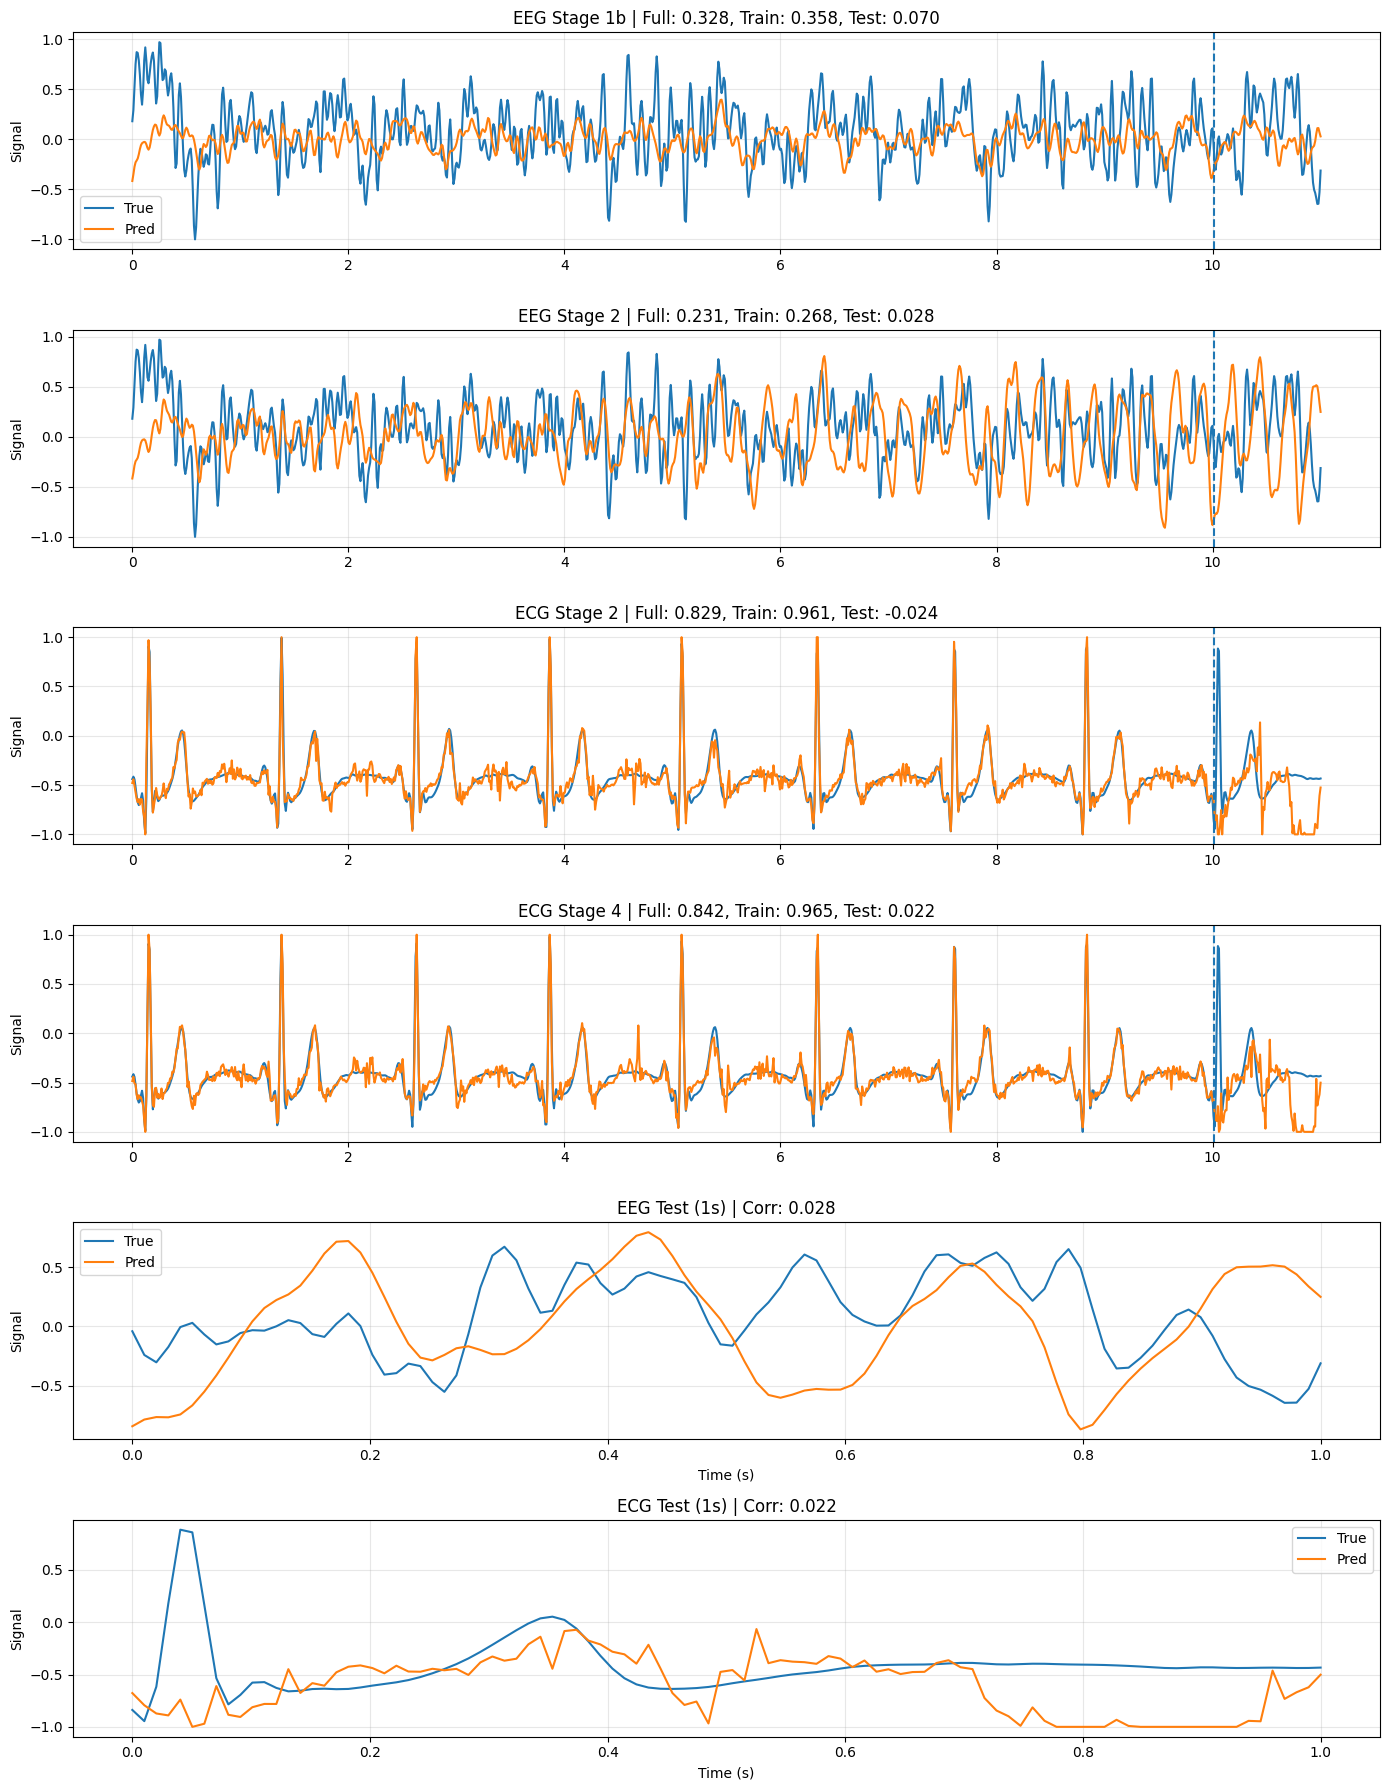

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FS = 100  # sampling frequency


def compute_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    return np.sum(x * y) / (np.sqrt(np.sum(x**2) * np.sum(y**2)) + 1e-8)


def load_all(region_dir, true_name, pred_name):
    return {
        "true_full": np.load(f"{region_dir}/{true_name}_full.npy"),
        "pred_full": np.load(f"{region_dir}/{pred_name}_full.npy"),
        "true_train": np.load(f"{region_dir}/{true_name}_train.npy"),
        "pred_train": np.load(f"{region_dir}/{pred_name}_train.npy"),
        "true_test": np.load(f"{region_dir}/{true_name}_test.npy"),
        "pred_test": np.load(f"{region_dir}/{pred_name}_test.npy"),
    }


def plot_all(region_dir):
    configs = [
        ("eeg_true", "eeg_stage1b", "EEG Stage 1b"),
        ("eeg_true", "eeg_stage2", "EEG Stage 2"),
        ("ecg_true", "ecg_stage2", "ECG Stage 2"),
        ("ecg_true", "ecg_stage4", "ECG Stage 4"),
    ]

    fig, axes = plt.subplots(6, 1, figsize=(14, 18))

    # -------- FULL PLOTS (same as before) --------
    for i, (true_name, pred_name, title) in enumerate(configs):
        data = load_all(region_dir, true_name, pred_name)

        true_full = data["true_full"]
        pred_full = data["pred_full"]
        true_train = data["true_train"]
        pred_train = data["pred_train"]
        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # correlations
        corr_full = compute_corr(pred_full, true_full)
        corr_train = compute_corr(pred_train, true_train)
        corr_test = compute_corr(pred_test, true_test)

        # time
        T = len(true_full)
        t = np.linspace(0, T / FS, T)
        T_train = len(true_train)

        ax = axes[i]
        ax.plot(t, true_full, label="True")
        ax.plot(t, pred_full, label="Pred")

        ax.axvline(t[T_train], linestyle="--")

        ax.set_title(
            f"{title} | Full: {corr_full:.3f}, Train: {corr_train:.3f}, Test: {corr_test:.3f}"
        )
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)

        if i == 0:
            ax.legend()

    # -------- ZOOMED TEST PLOTS (1 second) --------
    zoom_configs = [
        ("eeg_true", "eeg_stage2", "EEG Test (1s)"),
        ("ecg_true", "ecg_stage4", "ECG Test (1s)"),
    ]

    for j, (true_name, pred_name, title) in enumerate(zoom_configs):
        data = load_all(region_dir, true_name, pred_name)

        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # first 1 second
        n = min(FS, len(true_test))
        t = np.linspace(0, n / FS, n)

        corr = compute_corr(pred_test[:n], true_test[:n])

        ax = axes[4 + j]
        ax.plot(t, true_test[:n], label="True")
        ax.plot(t, pred_test[:n], label="Pred")

        ax.set_title(f"{title} | Corr: {corr:.3f}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Run
region_dir = os.path.join(save_root, f"region_{region_idx}")
os.makedirs(region_dir, exist_ok=True)
plot_all(region_dir)